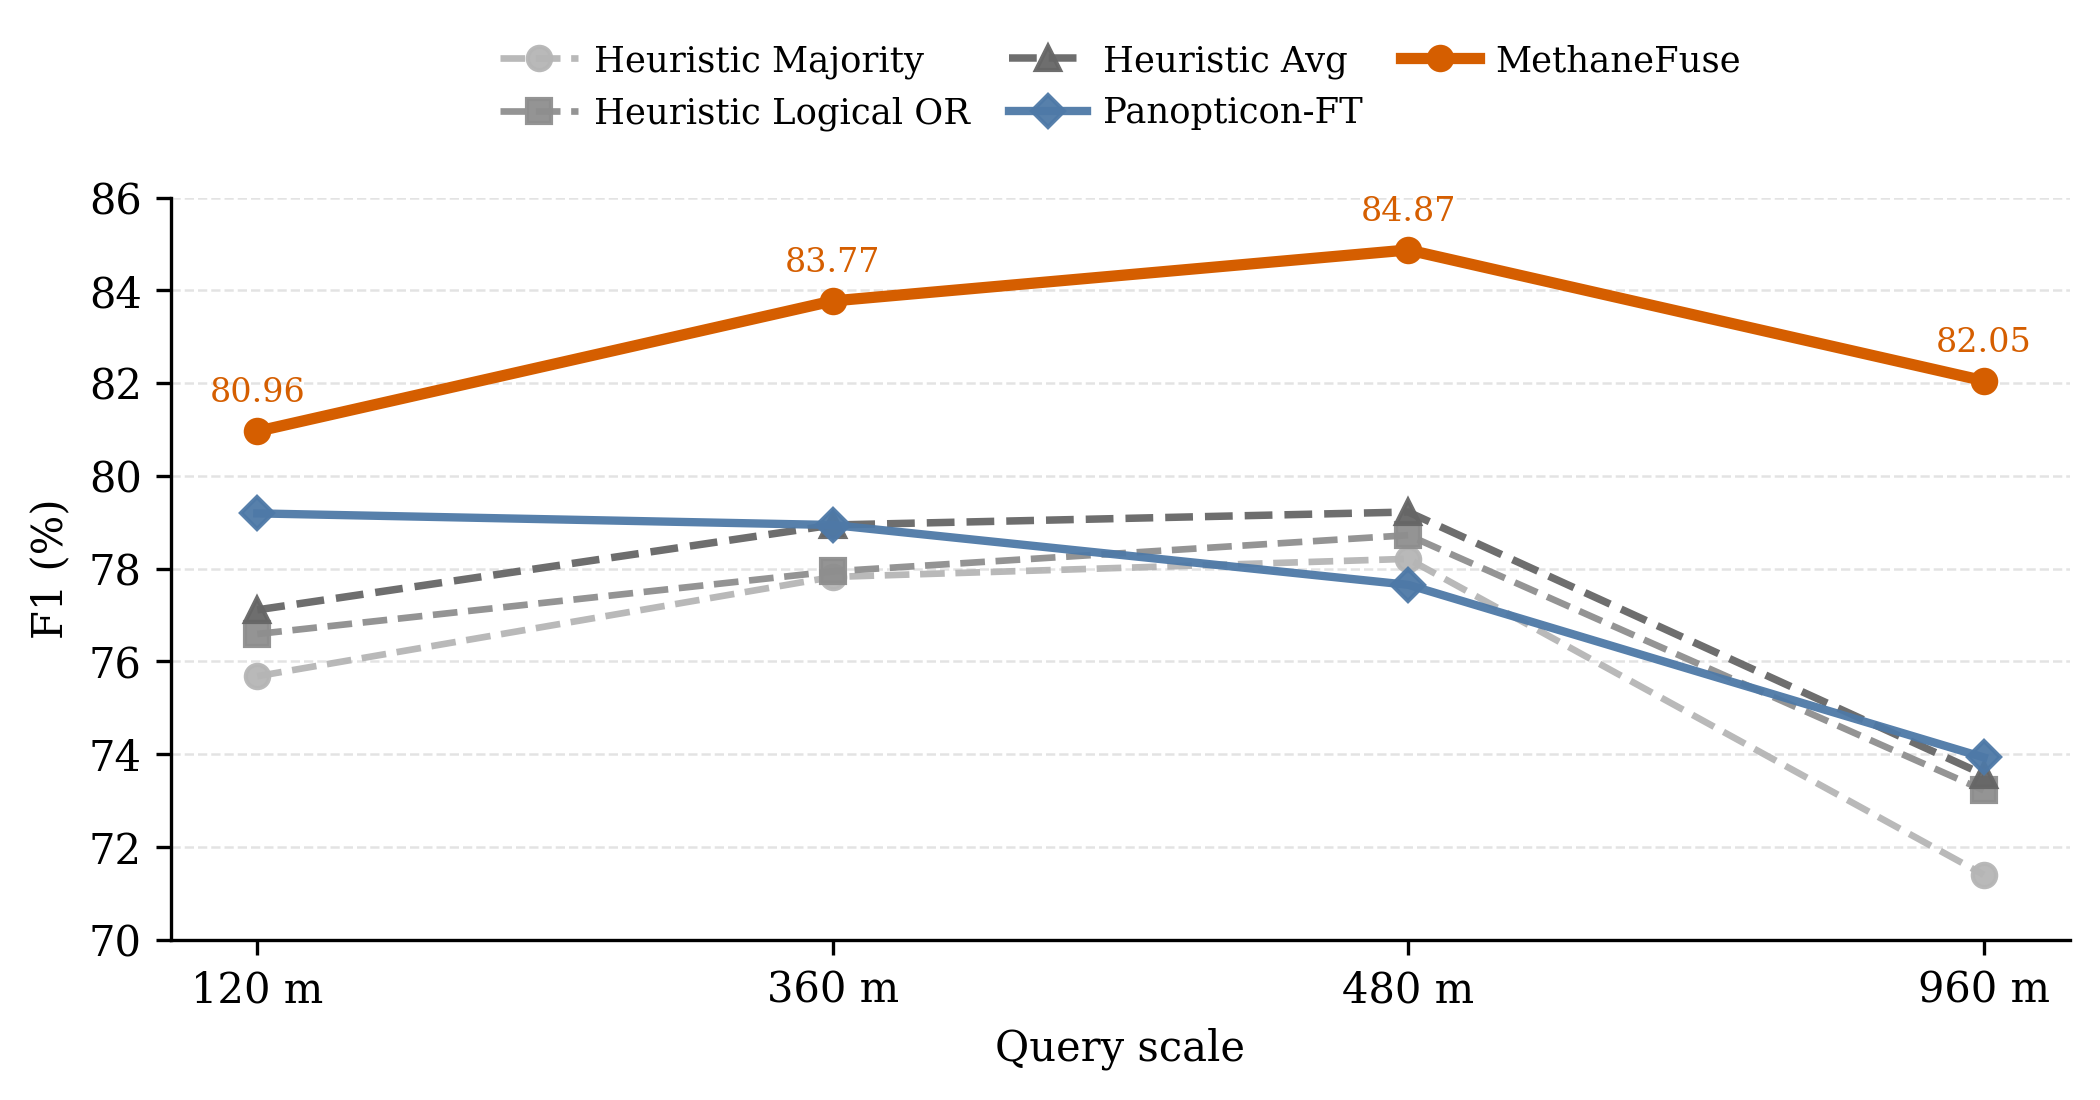

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Paper-style configuration
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Times", "Nimbus Roman"],
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def apply_paper_style(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
    ax.set_axisbelow(True)

# =========================================================
# Data: F1 scores across query scales
# values are percentages
# =========================================================
scales = ["120 m", "360 m", "480 m", "960 m"]
x = np.arange(len(scales))

data = {
    # Heuristic fusion baselines, recomputed with current calibration rules
    "Heuristic Majority": [75.68, 77.82, 78.21, 71.40],
    "Heuristic Logical OR": [76.59, 77.94, 78.72, 73.22],
    "Heuristic Avg": [77.11, 78.94, 79.22, 73.56],

    # EO representation transfer baselines
    "Panopticon-FT": [79.19, 78.94, 77.65, 73.93],
    # "SatMAE-FT": [69.74, 68.22, 67.60, 63.88],
    # "AnySat-FT": [60.77, 58.89, 58.90, 53.06],
    "SatMAE-FT": [np.nan, np.nan, np.nan, np.nan],  # Placeholder until we fill in results
    "AnySat-FT": [np.nan, np.nan, np.nan, np.nan],  # Placeholder until we fill in results

    # Proposed final model, from latest inferred Excel target_check overall_all
    "MethaneFuse": [80.96, 83.77, 84.87, 82.05],
}

# =========================================================
# Visual style
# Heuristic baselines: muted gray dashed lines
# EO-FT baselines: muted solid lines
# Ours: warm orange, thicker line
# =========================================================
style_map = {
    "Heuristic Majority": {
        "color": "#B5B5B5", "linestyle": "--", "marker": "o", "linewidth": 1.6,
        "alpha": 0.95
    },
    "Heuristic Logical OR": {
        "color": "#8E8E8E", "linestyle": "--", "marker": "s", "linewidth": 1.6,
        "alpha": 0.95
    },
    "Heuristic Avg": {
        "color": "#666666", "linestyle": "--", "marker": "^", "linewidth": 1.8,
        "alpha": 0.95
    },
    "Panopticon-FT": {
        "color": "#4E79A7", "linestyle": "-", "marker": "D", "linewidth": 2.0,
        "alpha": 0.95
    },
    "SatMAE-FT": {
        "color": "#59A14F", "linestyle": "-", "marker": "v", "linewidth": 2.0,
        "alpha": 0.95
    },
    "AnySat-FT": {
        "color": "#B07AA1", "linestyle": "-", "marker": "P", "linewidth": 2.0,
        "alpha": 0.95
    },
    "MethaneFuse": {
        "color": "#D55E00", "linestyle": "-", "marker": "o", "linewidth": 2.7,
        "alpha": 1.0
    },
}

# =========================================================
# Plot
# =========================================================
fig, ax = plt.subplots(figsize=(7.1, 3.9), dpi=300)

for method, y in data.items():
    y = np.array(y, dtype=float)

    # Skip placeholders until you fill SatMAE/AnySat results
    if np.all(np.isnan(y)):
        continue

    st = style_map[method]
    ax.plot(
        x, y,
        label=method,
        color=st["color"],
        linestyle=st["linestyle"],
        marker=st["marker"],
        linewidth=st["linewidth"],
        markersize=5.6,
        alpha=st["alpha"],
    )

# Annotate only the final model, to keep the figure clean
ada_vals = np.array(data["MethaneFuse"])
for xi, yi in zip(x, ada_vals):
    ax.annotate(
        f"{yi:.2f}",
        xy=(xi, yi),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color=style_map["MethaneFuse"]["color"],
    )

# Axes
ax.set_xticks(x)
ax.set_xticklabels(scales)
ax.set_ylabel("F1 (%)")
ax.set_xlabel("Query scale")
# ax.set_title("Query-level classification across query scales", pad=10, fontweight="bold")
ax.set_ylim(70, 86)

apply_paper_style(ax)

# Legend
ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.25),
    columnspacing=1.1,
    handlelength=2.2,
    handletextpad=0.45,
)

fig.tight_layout()

# Save
fig.savefig("fig_query_scale_f1_baselines.pdf", bbox_inches="tight")
fig.savefig("fig_query_scale_f1_baselines.png", bbox_inches="tight", dpi=600)
fig.savefig("fig_query_scale_f1_baselines.svg", bbox_inches="tight")

plt.show()

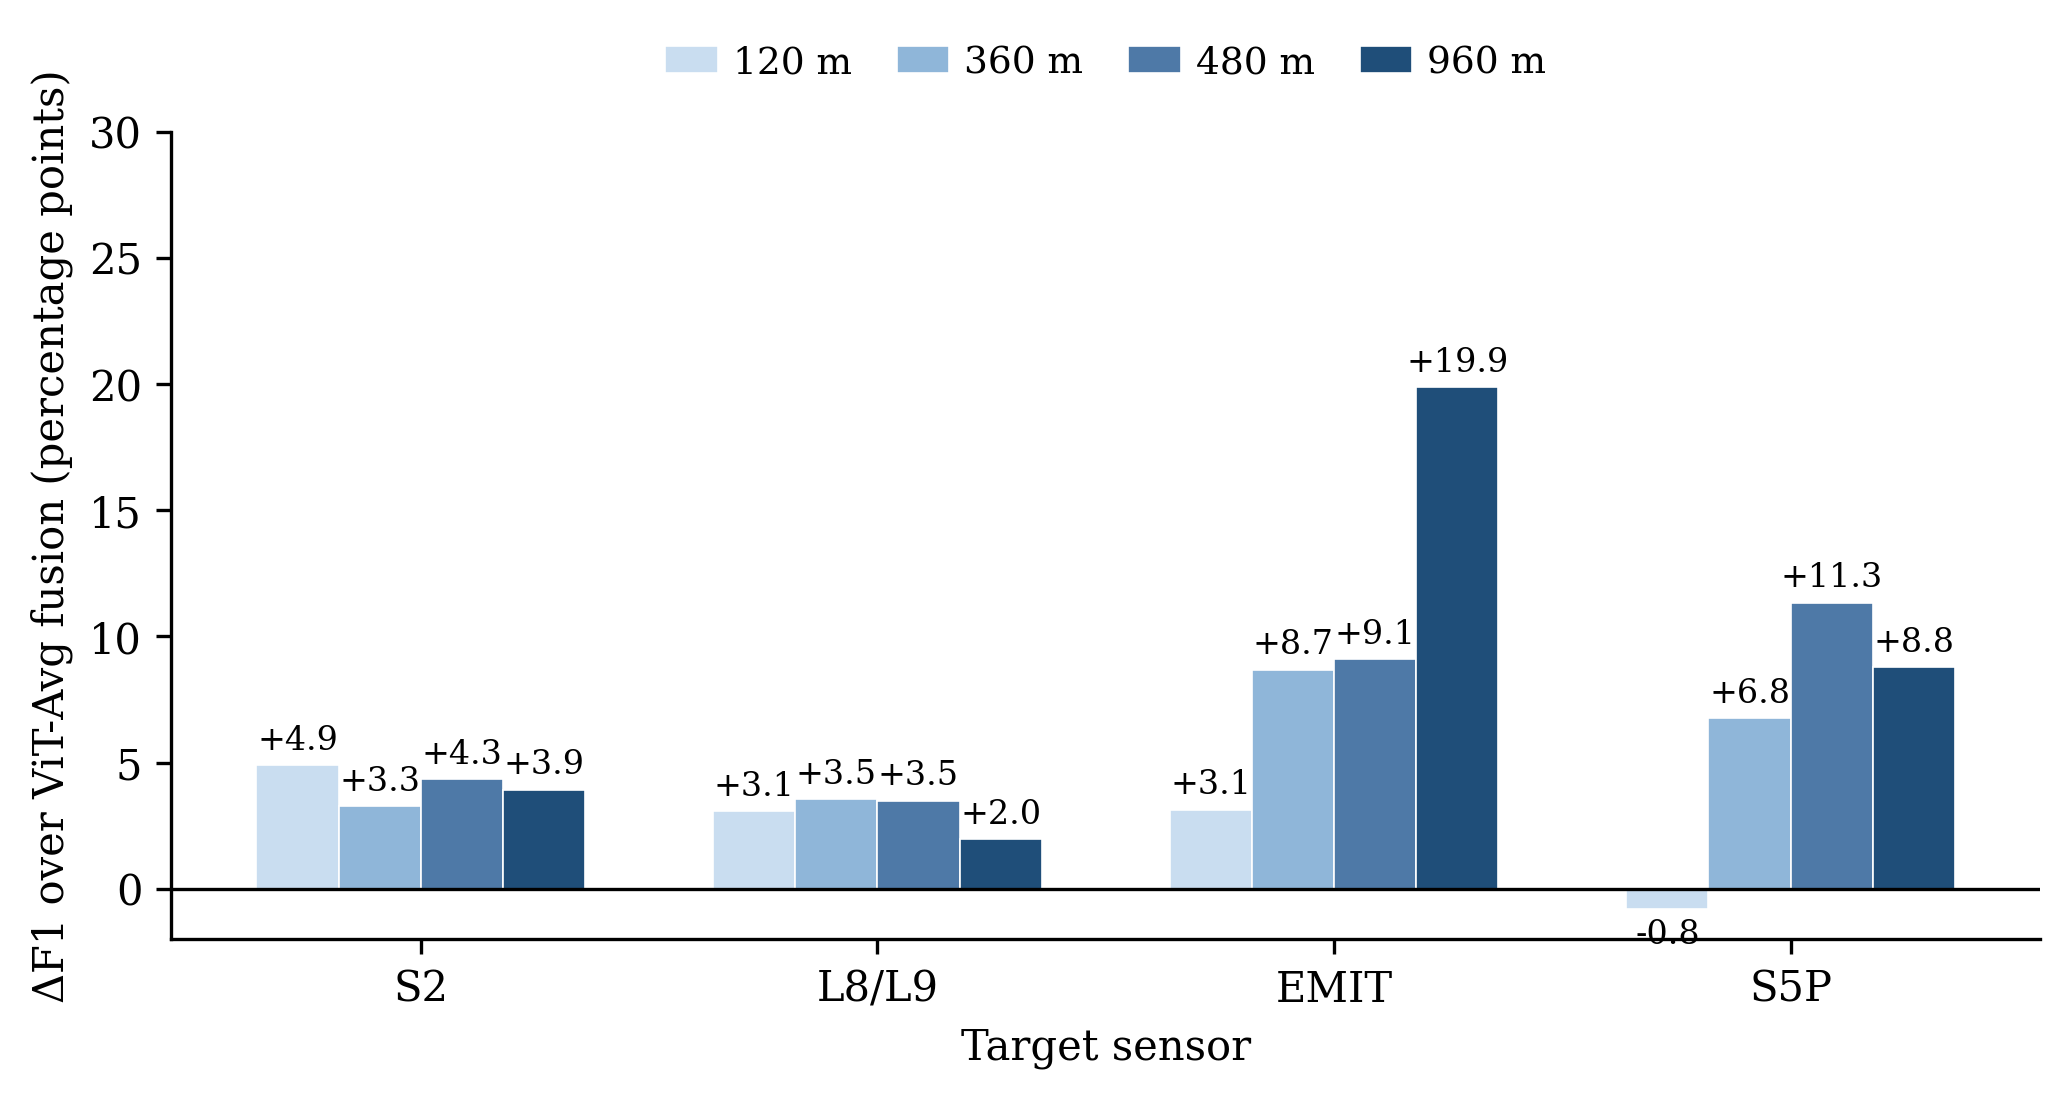

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Clean paper-style configuration
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times", "Nimbus Roman"],
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# Muted academic palette
COLORS = {
    "120m": "#C9DDF0",
    "360m": "#8FB6D9",
    "480m": "#4E79A7",
    "960m": "#1F4E79",
}

def apply_paper_style(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=3.5, width=0.8)
    ax.set_axisbelow(True)

# =========================================================
# Data: Sensor-valid only
# Delta F1 = MethaneFuse-Ada - Per-sensor ViT
# Values are percentage points
# =========================================================
sensors = ["S2", "L8/L9", "EMIT", "S5P"]
x = np.arange(len(sensors))
bar_width = 0.18

delta_120 = np.array([4.89, 3.08, 3.13, -0.82])

delta_360 = np.array([
    89.51 - 86.24,  # S2   = +3.27
    79.13 - 75.58,  # L89  = +3.55
    82.42 - 73.74,  # EMIT = +8.68
    84.36 - 77.60,  # S5P  = +6.76
])

delta_480 = np.array([
    88.75 - 84.41,  # S2   = +4.34
    81.81 - 78.32,  # L89  = +3.49
    84.07 - 74.98,  # EMIT = +9.09
    86.80 - 75.47,  # S5P  = +11.33
])
delta_960 = np.array([3.92, 1.96, 19.87, 8.79])

# =========================================================
# Plot
# =========================================================
fig, ax = plt.subplots(figsize=(7.0, 3.8), dpi=300)

bars_120 = ax.bar(
    x - 1.5 * bar_width, delta_120,
    width=bar_width, color=COLORS["120m"], label="120 m",
    edgecolor="white", linewidth=0.4
)
bars_360 = ax.bar(
    x - 0.5 * bar_width, delta_360,
    width=bar_width, color=COLORS["360m"], label="360 m",
    edgecolor="white", linewidth=0.4
)
bars_480 = ax.bar(
    x + 0.5 * bar_width, delta_480,
    width=bar_width, color=COLORS["480m"], label="480 m",
    edgecolor="white", linewidth=0.4
)
bars_960 = ax.bar(
    x + 1.5 * bar_width, delta_960,
    width=bar_width, color=COLORS["960m"], label="960 m",
    edgecolor="white", linewidth=0.4
)

ax.axhline(0, color="black", linewidth=0.8)

# Optional value labels
def annotate_bars(bars):
    for b in bars:
        h = b.get_height()
        if abs(h) < 0.05:
            label = "0.0"
        else:
            label = f"{h:+.1f}"
        va = "bottom" if h >= 0 else "top"
        offset = 0.35 if h >= 0 else -0.35
        ax.text(
            b.get_x() + b.get_width() / 2,
            h + offset,
            label,
            ha="center",
            va=va,
            fontsize=8,
        )

for bars in [bars_120, bars_360, bars_480, bars_960]:
    annotate_bars(bars)

ax.set_xticks(x)
ax.set_xticklabels(sensors)
ax.set_xlabel("Target sensor")
ax.set_ylabel(r"ΔF1 over ViT-Avg fusion (percentage points)")
ax.set_ylim(-2, 30)

apply_paper_style(ax)

ax.legend(
    frameon=False,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    handlelength=1.4,
    columnspacing=1.2,
    handletextpad=0.4,
)

fig.tight_layout()

fig.savefig("fig2_sensor_valid_delta_f1_clean.pdf", bbox_inches="tight")
fig.savefig("fig2_sensor_valid_delta_f1_clean.png", bbox_inches="tight", dpi=600)
fig.savefig("fig2_sensor_valid_delta_f1_clean.svg", bbox_inches="tight")

plt.show()

In [7]:
#!/usr/bin/env python3
from __future__ import annotations

from pathlib import Path
from typing import Iterable, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, FancyBboxPatch
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN


TRAIN_CSV = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/finalDataset_query/legacy_param_960m/manifest_time_train.csv"
TEST_CSV = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/finalDataset_query/legacy_param_960m/manifest_time_test.csv"

OUT_DIR = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/datasets_960m_cluster_split")
TRAIN_OUT = "manifest_time_train_960m_macroregion_by_plume.csv"
TEST_OUT = "manifest_time_test_960m_macroregion_by_plume.csv"
FIG_PNG = Path("/home/yuyao/panopticon/Pictures/960m_macroregion_split_map.png")
FIG_PDF = Path("/home/yuyao/panopticon/Pictures/960m_macroregion_split_map.pdf")

TILE_EDGE_M = 960.0
BLIND_GAP_M = 20.0
SMALL_EPS_FACTOR = 0.70
MACRO_EPS_M = 100_000.0
TEST_RATIO = 0.20
RANDOM_SEED = 42

MAX_REGION_FRACTION_OF_TARGET = 0.28
MIN_REGION_SIZE = 20
MIN_TEST_REGIONS = 8
MAX_TEST_REGIONS = 12
LOWER_TARGET_FRAC = 0.95
UPPER_TARGET_FRAC = 1.08
SEARCH_ITERS = 30_000

EARTH_RADIUS_M = 6371008.8
LAT_CANDIDATES = ("latitude", "lat", "plume_latitude", "center_lat", "centroid_lat")
LON_CANDIDATES = ("longitude", "lon", "plume_longitude", "center_lon", "centroid_lon")
PLUME_ID_CANDIDATES = ("plume_id", "plumeid", "plume_name", "source_id", "id")


def pick_first_existing(columns: Iterable[str], candidates: Sequence[str]) -> Optional[str]:
    colset = set(columns)
    for c in candidates:
        if c in colset:
            return c
    return None


def normalize_latlon_columns(df: pd.DataFrame) -> Tuple[pd.DataFrame, str, str]:
    lat_col = pick_first_existing(df.columns, LAT_CANDIDATES)
    lon_col = pick_first_existing(df.columns, LON_CANDIDATES)
    if lat_col is None or lon_col is None:
        raise ValueError(f"Could not find latitude/longitude columns in {list(df.columns)}")

    out = df.copy()
    out["_lat"] = pd.to_numeric(out[lat_col], errors="coerce")
    out["_lon"] = pd.to_numeric(out[lon_col], errors="coerce")
    out = out.dropna(subset=["_lat", "_lon"]).reset_index(drop=True)
    return out, lat_col, lon_col


def make_sample_id(df: pd.DataFrame) -> Tuple[pd.DataFrame, str]:
    plume_col = pick_first_existing(df.columns, PLUME_ID_CANDIDATES)
    out = df.copy()
    if plume_col is None:
        out["_sample_id"] = "row_" + out.index.astype(str)
        return out, "_sample_id"

    raw = out[plume_col].astype("string")
    missing = raw.isna() | raw.str.strip().eq("")
    out["_sample_id"] = raw.fillna("").str.strip()
    out.loc[missing, "_sample_id"] = "row_" + out.index[missing].astype(str)
    return out, "_sample_id"


def dbscan_haversine(lat_lon_deg: np.ndarray, eps_m: float) -> np.ndarray:
    return DBSCAN(
        eps=eps_m / EARTH_RADIUS_M,
        min_samples=1,
        metric="haversine",
    ).fit_predict(np.radians(lat_lon_deg))


def build_sample_table(df: pd.DataFrame, sample_col: str) -> pd.DataFrame:
    sample_df = (
        df.groupby(sample_col, as_index=False)
        .agg(_lat=("_lat", "mean"), _lon=("_lon", "mean"), label=("label", "max"))
        .rename(columns={sample_col: "sample_id"})
    )
    return sample_df


def build_macro_regions(sample_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    small_eps_m = (2.0 * TILE_EDGE_M + BLIND_GAP_M) * SMALL_EPS_FACTOR
    sample_df = sample_df.copy()
    sample_df["cluster_id"] = dbscan_haversine(sample_df[["_lat", "_lon"]].to_numpy(), small_eps_m)

    cluster_df = (
        sample_df.groupby("cluster_id")
        .agg(
            center_lat=("_lat", "mean"),
            center_lon=("_lon", "mean"),
            n_samples=("sample_id", "size"),
            pos=("label", "sum"),
        )
        .reset_index()
    )
    cluster_df["macro_region_id"] = dbscan_haversine(
        cluster_df[["center_lat", "center_lon"]].to_numpy(), MACRO_EPS_M
    )

    cluster_to_macro = dict(zip(cluster_df["cluster_id"], cluster_df["macro_region_id"]))
    sample_df["macro_region_id"] = sample_df["cluster_id"].map(cluster_to_macro)
    return sample_df, cluster_df


def select_test_macro_regions(sample_df: pd.DataFrame, region_df: pd.DataFrame) -> set[int]:
    target_n = len(sample_df) * TEST_RATIO
    max_region_n = target_n * MAX_REGION_FRACTION_OF_TARGET
    global_pos_rate = float(sample_df["label"].mean())

    region_stats = (
        region_df.groupby("macro_region_id")
        .agg(
            n=("n_samples", "sum"),
            pos=("pos", "sum"),
            center_lat=("center_lat", "mean"),
            center_lon=("center_lon", "mean"),
            n_clusters=("cluster_id", "size"),
        )
        .reset_index()
    )

    candidates = region_stats[
        (region_stats["n"] >= MIN_REGION_SIZE) & (region_stats["n"] <= max_region_n)
    ].copy()
    if len(candidates) < MIN_TEST_REGIONS:
        candidates = region_stats[region_stats["n"] <= max_region_n].copy()
    if len(candidates) < MIN_TEST_REGIONS:
        candidates = region_stats.copy()

    candidates = candidates.reset_index(drop=True)
    weights = np.sqrt(candidates["n"].to_numpy(dtype=float))
    weights = weights / weights.sum()
    rng = np.random.default_rng(RANDOM_SEED)

    best: tuple[float, list[int]] | None = None
    for _ in range(SEARCH_ITERS):
        order = rng.choice(len(candidates), size=len(candidates), replace=False, p=weights)
        selected: list[int] = []
        n = 0.0
        pos = 0.0

        for idx in order:
            row = candidates.iloc[int(idx)]
            if n + row.n > target_n * UPPER_TARGET_FRAC:
                continue
            selected.append(int(idx))
            n += float(row.n)
            pos += float(row.pos)
            if n >= target_n * LOWER_TARGET_FRAC and len(selected) >= MIN_TEST_REGIONS:
                break

        if not (target_n * LOWER_TARGET_FRAC <= n <= target_n * UPPER_TARGET_FRAC):
            continue
        if not (MIN_TEST_REGIONS <= len(selected) <= MAX_TEST_REGIONS):
            continue

        chosen = candidates.iloc[selected]
        pos_rate = pos / n
        lon_bins = len(np.unique(np.floor((chosen["center_lon"].to_numpy() + 180.0) / 40.0)))
        lat_bins = len(np.unique(np.floor((chosen["center_lat"].to_numpy() + 90.0) / 25.0)))
        spread_bonus = min(lon_bins, 6) * 0.012 + min(lat_bins, 4) * 0.006

        cost = (
            abs(n - target_n) / target_n
            + 0.30 * abs(pos_rate - global_pos_rate)
            + 0.004 * max(0, len(selected) - 10)
            - spread_bonus
        )

        if best is None or cost < best[0]:
            best = (float(cost), selected)

    if best is None:
        raise RuntimeError("Could not find a macro-region split satisfying the constraints.")

    chosen = candidates.iloc[best[1]]
    return set(chosen["macro_region_id"].astype(int))


def save_split(df: pd.DataFrame, sample_df: pd.DataFrame, sample_col: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    sample_to_cluster = dict(zip(sample_df["sample_id"], sample_df["cluster_id"]))
    sample_to_macro = dict(zip(sample_df["sample_id"], sample_df["macro_region_id"]))
    sample_to_split = dict(zip(sample_df["sample_id"], sample_df["split"]))

    df = df.copy()
    df["cluster_id"] = df[sample_col].map(sample_to_cluster)
    df["macro_region_id"] = df[sample_col].map(sample_to_macro)
    df["split"] = df[sample_col].map(sample_to_split)

    train_out = df[df["split"] == "train"].copy()
    test_out = df[df["split"] == "test"].copy()
    drop_cols = ["_lat", "_lon", "_orig_split", "split"]
    train_out = train_out.drop(columns=[c for c in drop_cols if c in train_out.columns])
    test_out = test_out.drop(columns=[c for c in drop_cols if c in drop_cols if c in test_out.columns])

    OUT_DIR.mkdir(parents=True, exist_ok=True)
    train_out.to_csv(OUT_DIR / TRAIN_OUT, index=False)
    test_out.to_csv(OUT_DIR / TEST_OUT, index=False)
    return train_out, test_out


def add_region_ellipses(ax: plt.Axes, sample_df: pd.DataFrame) -> None:
    test_regions = sample_df.loc[sample_df["split"] == "test", "macro_region_id"].unique()
    for rid in test_regions:
        part = sample_df[(sample_df["macro_region_id"] == rid) & (sample_df["split"] == "test")]
        if len(part) < 3:
            continue
        lon = part["_lon"].to_numpy()
        lat = part["_lat"].to_numpy()
        width = max(np.std(lon) * 5.0, 1.0)
        height = max(np.std(lat) * 5.0, 0.8)
        patch = Ellipse(
            (float(np.mean(lon)), float(np.mean(lat))),
            width=width,
            height=height,
            facecolor="#D95F02",
            edgecolor="none",
            alpha=0.08,
            zorder=1,
        )
        ax.add_patch(patch)


def add_test_legend_box(
    ax: plt.Axes,
    test_regions: list[int],
    region_color: dict[int, str],
) -> None:
    """Draw a custom top-right legend box with colored triangle markers."""
    box_x, box_y = 0.725, 0.875
    box_w, box_h = 0.255, 0.105

    legend_box = FancyBboxPatch(
        (box_x, box_y),
        box_w,
        box_h,
        boxstyle="round,pad=0.012,rounding_size=0.006",
        transform=ax.transAxes,
        facecolor="white",
        edgecolor="#D0D0D0",
        linewidth=0.8,
        alpha=0.94,
        zorder=10,
        clip_on=False,
    )
    ax.add_patch(legend_box)

    shown_regions = test_regions[: min(10, len(test_regions))]
    tri_colors = [region_color[rid] for rid in shown_regions]

    tri_x = np.linspace(box_x + 0.025, box_x + 0.125, len(tri_colors))
    tri_y = np.full(len(tri_colors), box_y + box_h - 0.032)

    ax.scatter(
        tri_x,
        tri_y,
        transform=ax.transAxes,
        marker="^",
        s=24,
        c=tri_colors,
        edgecolors="white",
        linewidths=0.25,
        zorder=11,
        clip_on=False,
    )

    ax.text(
        box_x + box_w - 0.012,
        box_y + box_h - 0.032,
        "Test plumes",
        transform=ax.transAxes,
        ha="right",
        va="center",
        fontsize=7.2,
        zorder=11,
    )

    ax.text(
        box_x + box_w - 0.012,
        box_y + 0.030,
        f"Colored test macro-regions: {len(test_regions)}",
        transform=ax.transAxes,
        ha="right",
        va="center",
        fontsize=7.2,
        zorder=11,
    )


def plot_map(sample_df: pd.DataFrame) -> None:
    plt.rcParams.update(
        {
            "font.family": "DejaVu Sans",
            "font.size": 7.5,
            "axes.titlesize": 9,
            "axes.labelsize": 8.5,
            "legend.fontsize": 7.5,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    )

    train = sample_df[sample_df["split"] == "train"]
    test = sample_df[sample_df["split"] == "test"]
    test_regions = sorted(test["macro_region_id"].unique())

    palette = [
        "#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00",
        "#56B4E9", "#7F3C8D", "#11A579", "#E73F74", "#3969AC",
        "#F2B701", "#80BA5A", "#E68310", "#008695", "#CF1C90",
    ]
    region_color = {rid: palette[i % len(palette)] for i, rid in enumerate(test_regions)}

    fig, ax = plt.subplots(figsize=(7.1, 3.7), dpi=300)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.scatter(
        train["_lon"],
        train["_lat"],
        marker="o",
        s=7.8,
        c="#2F6FA8",
        alpha=0.58,
        linewidths=0,
        label="Train plumes",
        zorder=1,
    )

    for rid in test_regions:
        part = test[test["macro_region_id"] == rid]
        ax.scatter(
            part["_lon"],
            part["_lat"],
            marker="^",
            s=23,
            c=region_color[rid],
            alpha=0.92,
            linewidths=0.28,
            edgecolors="white",
            zorder=3,
        )

    ax.set_xlim(-130, 155)
    ax.set_ylim(-52, 75)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xticks(np.arange(-120, 181, 40))
    ax.set_yticks(np.arange(-40, 81, 20))
    ax.grid(False)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color("#3A3A3A")

    train_legend = ax.legend(
        loc="upper left",
        frameon=True,
        facecolor="white",
        edgecolor="#D0D0D0",
        framealpha=0.94,
        borderpad=0.45,
        handletextpad=0.6,
    )
    for handle in train_legend.legend_handles:
        handle.set_alpha(1.0)

    add_test_legend_box(ax, test_regions, region_color)

    fig_png = Path(FIG_PNG)
    fig_pdf = Path(FIG_PDF)
    if not fig_png.is_absolute():
        fig_png = OUT_DIR / "cluster_viz" / fig_png
    if not fig_pdf.is_absolute():
        fig_pdf = OUT_DIR / "cluster_viz" / fig_pdf

    fig_png.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(fig_png, bbox_inches="tight", dpi=600)
    fig.savefig(fig_pdf, bbox_inches="tight")
    plt.close(fig)


def main() -> None:
    train_df = pd.read_csv(TRAIN_CSV)
    test_df = pd.read_csv(TEST_CSV)
    train_df["_orig_split"] = "train"
    test_df["_orig_split"] = "test"
    df = pd.concat([train_df, test_df], ignore_index=True)

    df, _, _ = normalize_latlon_columns(df)
    df, sample_col = make_sample_id(df)
    sample_df = build_sample_table(df, sample_col)
    sample_df, region_df = build_macro_regions(sample_df)

    test_regions = select_test_macro_regions(sample_df, region_df)
    sample_df["split"] = np.where(sample_df["macro_region_id"].isin(test_regions), "test", "train")

    train_out, test_out = save_split(df, sample_df, sample_col)
    plot_map(sample_df)

    test_sample = sample_df[sample_df["split"] == "test"]
    train_sample = sample_df[sample_df["split"] == "train"]

    print(f"sample-level train={len(train_sample)}, test={len(test_sample)}, test_frac={len(test_sample)/len(sample_df):.3f}")
    print(f"row-level train={len(train_out)}, test={len(test_out)}")
    print(f"small DBSCAN clusters={sample_df['cluster_id'].nunique()}")
    print(f"macro regions total={sample_df['macro_region_id'].nunique()}, test={test_sample['macro_region_id'].nunique()}")
    print(f"train csv: {OUT_DIR / TRAIN_OUT}")
    print(f"test csv : {OUT_DIR / TEST_OUT}")
    print(f"figure png: {FIG_PNG}")
    print(f"figure pdf: {FIG_PDF}")
    print("\nSelected test macro-regions:")
    print(
        test_sample.groupby("macro_region_id")
        .agg(n=("sample_id", "size"), pos_rate=("label", "mean"), lat=("_lat", "mean"), lon=("_lon", "mean"))
        .sort_values("lon")
        .round(3)
        .to_string()
    )


if __name__ == "__main__":
    main()

sample-level train=6094, test=1523, test_frac=0.200
row-level train=121527, test=36484
small DBSCAN clusters=2776
macro regions total=349, test=10
train csv: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/datasets_960m_cluster_split/manifest_time_train_960m_macroregion_by_plume.csv
test csv : /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/datasets_960m_cluster_split/manifest_time_test_960m_macroregion_by_plume.csv
figure png: /home/yuyao/panopticon/Pictures/960m_macroregion_split_map.png
figure pdf: /home/yuyao/panopticon/Pictures/960m_macroregion_split_map.pdf

Selected test macro-regions:
                   n  pos_rate     lat      lon
macro_region_id                                
26                24     1.000  45.710 -120.323
3                125     0.856  36.805 -107.764
15                61     0.852  33.446  -87.209
153               40     0.950 -34.621  -58.612
60               128     0.969  31.763    5.949
49                81     0.877  32.109